Forecast Error Analysis

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import httpx
from datetime import datetime

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

1. Data Fetching and Preparation
We fetch the `WINDFOR` and `FUELHH` datasets from the Elexon BMRS API from January 2025 onwards.

In [8]:
BASE_URL = "https://data.elexon.co.uk/bmrs/api/v1"
start_date = "2025-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")

print("Fetching Actuals...")
res_act = httpx.get(f"{BASE_URL}/datasets/FUELHH/stream", params={
    "settlementDateFrom": start_date,
    "settlementDateTo": end_date,
    "fuelType": "WIND"
}, timeout=60)
actuals_data = [x for x in res_act.json() if x.get('fuelType') == 'WIND']
df_actuals = pd.DataFrame(actuals_data)
df_actuals['startTime'] = pd.to_datetime(df_actuals['startTime'], utc=True)
df_actuals = df_actuals[['startTime', 'generation']].rename(columns={'generation': 'actual_mw'})

print("Fetching Forecasts...")
res_fore = httpx.get(f"{BASE_URL}/datasets/WINDFOR/stream", params={
    "publishDateTimeFrom": f"{start_date}T00:00:00Z",
    "publishDateTimeTo": f"{end_date}T00:00:00Z",
}, timeout=120)
df_forecasts = pd.DataFrame(res_fore.json())
df_forecasts['startTime'] = pd.to_datetime(df_forecasts['startTime'], utc=True)
df_forecasts['publishTime'] = pd.to_datetime(df_forecasts['publishTime'], utc=True)
df_forecasts = df_forecasts.rename(columns={'generation': 'forecast_mw'})

print(f"Loaded {len(df_actuals)} actuals and {len(df_forecasts)} forecasts.")

Fetching Actuals...
Fetching Forecasts...
Loaded 21234 actuals and 257982 forecasts.


In [9]:
df_forecasts['horizon_hours'] = (df_forecasts['startTime'] - df_forecasts['publishTime']).dt.total_seconds() / 3600
df_forecasts = df_forecasts[(df_forecasts['horizon_hours'] >= 0) & (df_forecasts['horizon_hours'] <= 48)].copy()

df_merged = pd.merge(df_actuals, df_forecasts, on='startTime', how='inner')
df_merged['error_mw'] = df_merged['forecast_mw'] - df_merged['actual_mw']
df_merged['abs_error_mw'] = df_merged['error_mw'].abs()
df_merged.head()

,startTime,actual_mw,dataset,publishTime,forecast_mw,horizon_hours,error_mw,abs_error_mw
0,2026-03-19 08:00:00+00:00,2336,WINDFOR,2026-03-18 22:30:00+00:00,2279,9.5,-57,57
1,2026-03-19 08:00:00+00:00,2336,WINDFOR,2026-03-18 18:30:00+00:00,2213,13.5,-123,123
2,2026-03-19 08:00:00+00:00,2336,WINDFOR,2026-03-18 15:30:00+00:00,2150,16.5,-186,186
3,2026-03-19 08:00:00+00:00,2336,WINDFOR,2026-03-18 11:30:00+00:00,2101,20.5,-235,235
4,2026-03-19 08:00:00+00:00,2336,WINDFOR,2026-03-18 09:30:00+00:00,2021,22.5,-315,315


2. Overall Error Characteristics
Calculate Mean, Median, and P99 Error.

In [10]:
mean_err = df_merged['error_mw'].mean()
mean_abs_err = df_merged['abs_error_mw'].mean()
median_abs_err = df_merged['abs_error_mw'].median()
p99_abs_err = df_merged['abs_error_mw'].quantile(0.99)

print(f"Mean Error (Bias): {mean_err:.2f} MW")
print(f"Mean Absolute Error (MAE): {mean_abs_err:.2f} MW")
print(f"Median Absolute Error: {median_abs_err:.2f} MW")
print(f"99th Percentile (P99) Absolute Error: {p99_abs_err:.2f} MW")


Mean Error (Bias): 1338.71 MW
Mean Absolute Error (MAE): 1676.44 MW
Median Absolute Error: 1287.00 MW
99th Percentile (P99) Absolute Error: 5935.80 MW


Write your analytical conclusions for overall metrics here:


3. Variation in Error as Forecast Horizon Changes
How does the predictability of wind change as we move further out from the target time?

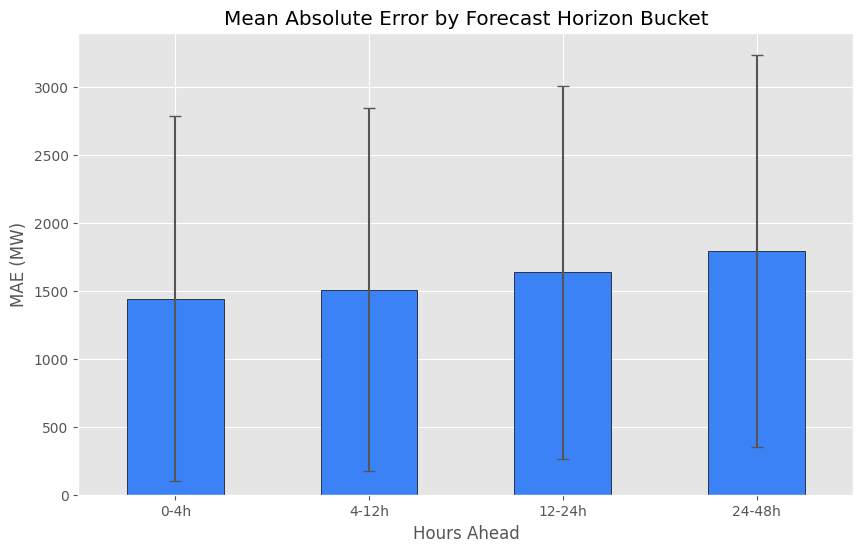

,mean,median,std
horizon_bucket,,,
0-4h,1441.846633,1000.5,1344.568872
4-12h,1508.680191,1101.0,1334.756378
12-24h,1635.648142,1258.0,1373.818797
24-48h,1793.316014,1425.0,1443.341410


In [11]:
bins = [0, 4, 12, 24, 48]
labels = ['0-4h', '4-12h', '12-24h', '24-48h']
df_merged['horizon_bucket'] = pd.cut(df_merged['horizon_hours'], bins=bins, labels=labels)

horizon_grouped = df_merged.groupby('horizon_bucket', observed=False)['abs_error_mw'].agg(['mean', 'median', 'std'])

horizon_grouped['mean'].plot(kind='bar', color='#3b82f6', edgecolor='black', yerr=horizon_grouped['std'], capsize=4)
plt.title('Mean Absolute Error by Forecast Horizon Bucket')
plt.ylabel('MAE (MW)')
plt.xlabel('Hours Ahead')
plt.xticks(rotation=0)
plt.show()

display(horizon_grouped)

Write your analytical conclusions for horizon variation here:


4. Error at Different Times of the Day
Does the time of day affect forecast accuracy?

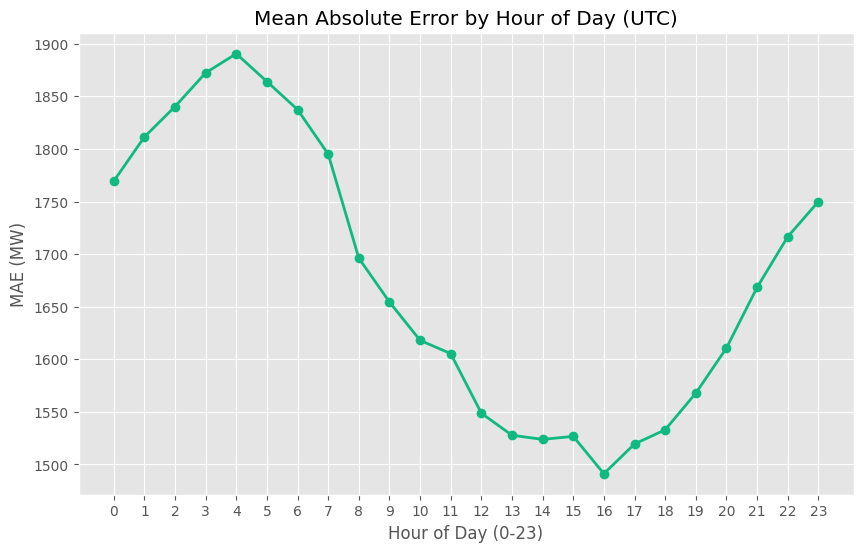

In [12]:
df_merged['hour_of_day'] = df_merged['startTime'].dt.hour

hourly_mae = df_merged.groupby('hour_of_day')['abs_error_mw'].mean()

hourly_mae.plot(kind='line', marker='o', color='#10b981', linewidth=2)
plt.title('Mean Absolute Error by Hour of Day (UTC)')
plt.ylabel('MAE (MW)')
plt.xlabel('Hour of Day (0-23)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

Analytical conclusions : Forecast accuracy drops during morning and evening transitions due to rapid atmospheric changes, increasing wind volatility. These high-error periods coincide with peak electricity demand, requiring heightened grid management and operational vigilance.

